<a href="https://colab.research.google.com/github/yvrjsharma/HugginFace_Gradio/blob/main/Llama3_2_Vision_Chatbot_with_Gradio5_cp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLAMA 3.2 Vision

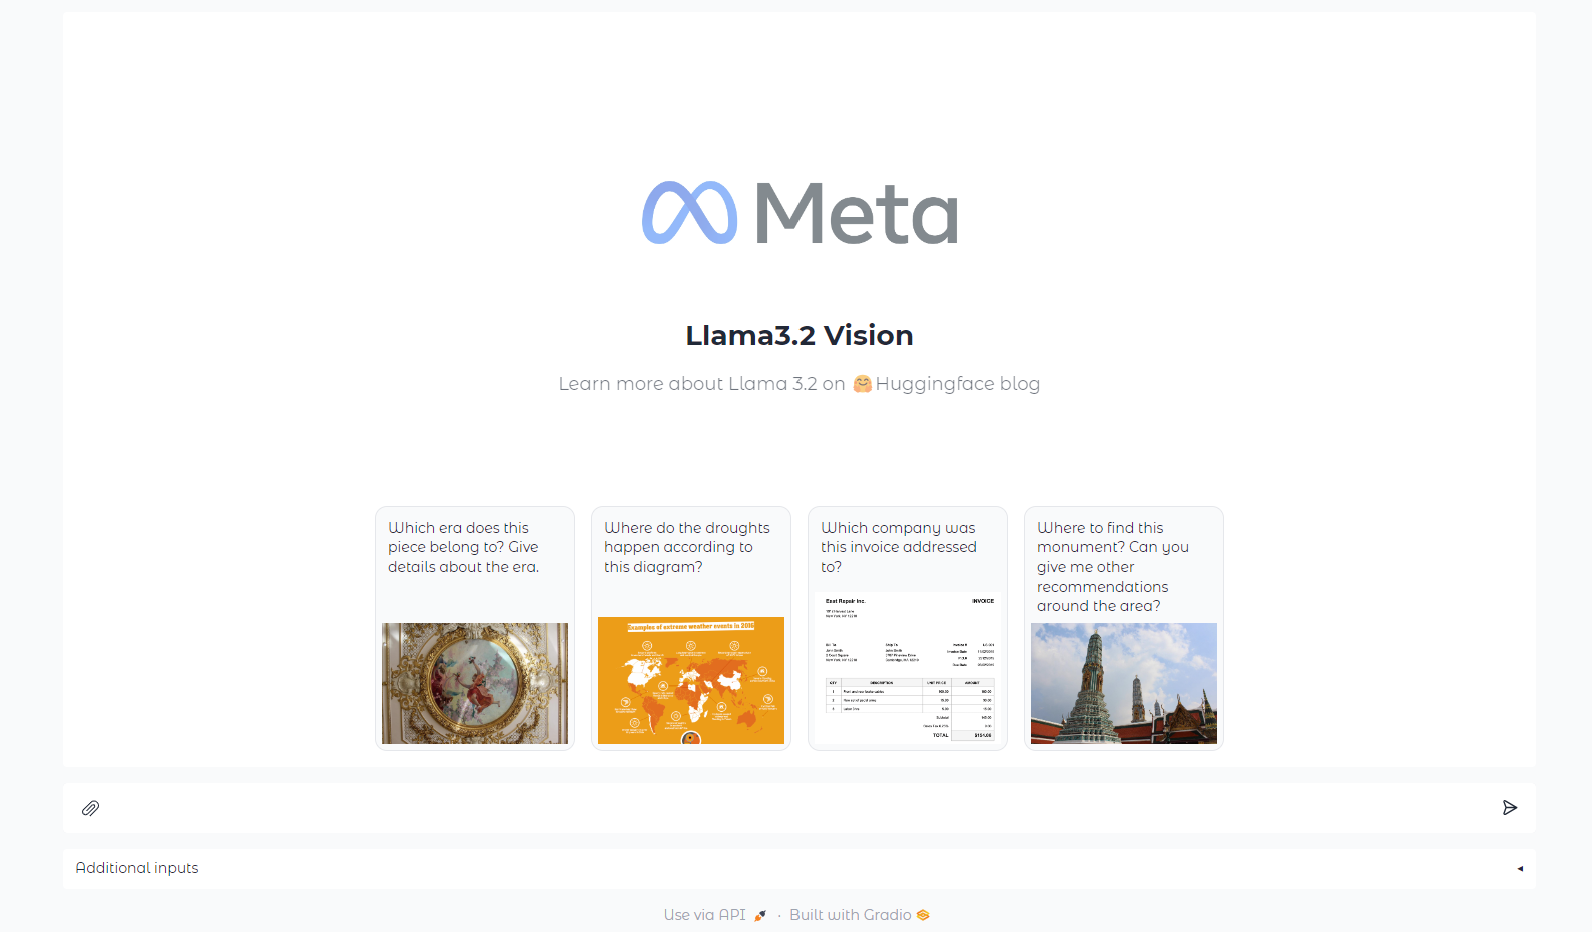

## Install Gradio 5 (Beta) and required packages

In [1]:
!pip install -q gradio --pre

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.2/319.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.2 MB/s eta 0:00:00


In [2]:
!pip show gradio

Name: gradio
Version: 5.0.0b3
Summary: Python library for easily interacting with trained machine learning models
Home-page: https://github.com/gradio-app/gradio
Author: 
Author-email: Abubakar Abid <gradio-team@huggingface.co>, Ali Abid <gradio-team@huggingface.co>, Ali Abdalla <gradio-team@huggingface.co>, Dawood Khan <gradio-team@huggingface.co>, Ahsen Khaliq <gradio-team@huggingface.co>, Pete Allen <gradio-team@huggingface.co>, Ömer Faruk Özdemir <gradio-team@huggingface.co>, Freddy A Boulton <gradio-team@huggingface.co>, Hannah Blair <gradio-team@huggingface.co>
License: 
Location: /usr/local/lib/python3.10/dist-packages
Requires: aiofiles, anyio, fastapi, ffmpy, gradio-client, httpx, huggingface-hub, jinja2, markupsafe, numpy, orjson, packaging, pandas, pillow, pydantic, pydub, python-multipart, pyyaml, ruff, semantic-version, tomlkit, typer, typing-extensions, uvicorn
Required-by: 


In [3]:
!pip install huggingface_hub hf_transfer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.3 MB/s eta 0:00:00


In [4]:
!pip install --upgrade transformers # or >= 4.45.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 98.1 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.44.2
    Uninstalling transformers-4.44.2:
      Successfully uninstalled transformers-4.44.2


## Setup huggingface token as an env. variable

In [5]:
import os
os.environ["HF_TOKEN"] = "hf_xx"

## Import required libraries and load the VLM model

In [6]:
from transformers import MllamaForConditionalGeneration, AutoProcessor, TextIteratorStreamer
from PIL import Image
import requests
import torch
from threading import Thread
import gradio as gr
from gradio import FileData
import time
ckpt = "meta-llama/Llama-3.2-11B-Vision-Instruct"
CUDA_LAUNCH_BLOCKING=1
model = MllamaForConditionalGeneration.from_pretrained(ckpt,
    torch_dtype=torch.bfloat16).to("cuda")
processor = AutoProcessor.from_pretrained(ckpt)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/5.07k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/89.4k [00:00<?, ?B/s]

model-00001-of-00005.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00005.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.15k [00:00<?, ?B/s]

In [7]:
!git clone https://huggingface.co/spaces/huggingface-projects/llama-3.2-vision-11B

Cloning into 'llama-3.2-vision-11B'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 25 (delta 4), reused 0 (delta 0), pack-reused 4 (from 1)
Unpacking objects: 100% (25/25), 1.12 MiB | 3.42 MiB/s, done.


## Main Gradio inference function

In [8]:
def generate(message, history, max_new_tokens):
    print("inside generate")
    print(f"message - {message}")
    print(f"history - {history}")

    txt = message["text"]

    messages= []
    messages2= []
    images = []
    images2 = []

    messages2 = [{k: {'path': v[0]} if k == 'content' and isinstance(v, tuple) else v for k, v in d.items() if k != 'metadata'} for d in history]
    print(f"message[files] - {message['files']}")

    for x in message["files"]:
        messages2.append({"role": "user", "content": {"path": x}})
        images2.append(Image.open(x).convert("RGB"))
    print(f" messages 2 - {messages2}")

    if message["text"] is not None:
        messages2.append({"role": "user", "content": message["text"]})
    print(f"messages 2 - {messages2}")

    for i in range(len(history)): #enumerate(history): #i, msg
        if isinstance(history[i]['content'], tuple):
            messages.append({"role": "user", "content": [{"type": "text", "text": history[i+1]['content']}, {"type": "image"}]})
            messages.append({"role": "assistant", "content": [{"type": "text", "text": history[i+2]['content']}]})
            images.append(Image.open(history[i]['content'][0]).convert("RGB"))
            if i+3 == len(history):
                break
            else:
                i+=3
                continue
        else:
            messages.append({"role": "user", "content": [{"type": "text", "text": history[i]['content']}]})
            messages.append({"role": "assistant", "content": [{"type": "text", "text": history[i+1]['content']}]})
            if i+2 == len(history):
                break
            else:
              i+=2
              continue
    print(f"messages after history appends - {messages}")
    print(f"images after history images append- {images}")

    # add current message
    if len(message["files"]) == 1:

        if isinstance(message["files"][0], str): # examples
            image = Image.open(message["files"][0]).convert("RGB")
        else: # regular input
            image = Image.open(message["files"][0]["path"]).convert("RGB")
        images.append(image)
        messages.append({"role": "user", "content": [{"type": "text", "text": txt}, {"type": "image"}]})
    else:
        messages.append({"role": "user", "content": [{"type": "text", "text": txt}]})
    print(f"messages after current_message append - {messages}")
    print(f"images after current image append- {images}")

    texts = processor.apply_chat_template(messages, add_generation_prompt=True)
    print(f"texts - {texts}")

    if images == []:
        inputs = processor(text=texts, return_tensors="pt").to("cuda")
    else:
        inputs = processor(text=texts, images=images, return_tensors="pt").to("cuda")
    print(f"inputs type - {type(inputs)}")

    streamer = TextIteratorStreamer(processor, skip_special_tokens=True, skip_prompt=True)
    generation_kwargs = dict(inputs, streamer=streamer, max_new_tokens=max_new_tokens)
    generated_text = ""
    thread = Thread(target=model.generate, kwargs=generation_kwargs)
    thread.start()
    buffer = ""

    messages2.append({"role": "assistant", "content": ""})
    for new_text in streamer:
        buffer += new_text
        messages2[-1]['content'] = buffer
        yield messages2, None
    print(f"messages FINAL - {messages2}")


## Launch Gradio 5 Multimodal chatbot

In [15]:

def handle_retry(history, retry_data: gr.RetryData):
    print("inside retry")
    print(f"history - {history}")
    new_history = history[:retry_data.index]
    previous_prompt = history[retry_data.index]['content']
    #yield from generate(previous_prompt, chat_history = new_history, max_new_tokens = 1024, temperature = 0.6, top_p = 0.9, top_k = 50, repetition_penalty = 1.2)
    yield from generate(previous_prompt, history = new_history, max_new_tokens=250)

def handle_like(data: gr.LikeData):
    if data.liked:
        print("You upvoted this response: ", data.value)
    else:
        print("You downvoted this response: ", data.value)

def handle_undo(history, undo_data: gr.UndoData):
    print("inside undo")
    print(f"history - {history}")
    print(f"undo_data value - {undo_data.value}")
    print(f"undo_data index - {undo_data.index}")
    chatbot = history[:undo_data.index]
    prompt = history[undo_data.index]['content']
    return chatbot, prompt

def suggestion_fill(max_new_tokens, data: gr.SelectData):
    print("inside chat_examples_fill")
    print("SelectData.value: ", data.value)
    print("SelectData.index : ", data.index)
    data.value['files'] = [data.value['files'][0]['path']]
    #yield from generate(data.value['text'], chat_history = [], max_new_tokens = 1024, temperature = 0.6, top_p = 0.9, top_k = 50, repetition_penalty = 1.2)
    yield from generate(data.value, history = [], max_new_tokens=1000)

PLACEHOLDER = """<div style="padding: 20px; text-align: center; display: flex; flex-direction: column; align-items: center;">
   <img src="https://ysharma-dummy-chat-app.hf.space/file=/tmp/gradio/c21ff9c8e7ecb2f7d957a72f2ef03c610ac7bbc4/Meta_lockup_positive%20primary_RGB_small.jpg" style="width: 80%; max-width: 550px; height: auto; opacity: 0.55; margin-bottom: 10px;">
   <h1 style="font-size: 28px; margin: 0;">Llama3.2 Vision</h1>
   <p style="font-size: 18px;  opacity: 0.65;">
       <a href="https://huggingface.co/blog/llama32" target="_blank" style="color: inherit; text-decoration: none;">Learn more about Llama 3.2 on 🤗Huggingface blog</a>
   </p>
</div>"""

with gr.Blocks(theme=gr.themes.Soft(), fill_height=True) as demo:
    with gr.Column(elem_id="container", scale=1):
        chatbot = gr.Chatbot(
            label="Llama3.2 11B Vision Instruct Chatbot using Gradio 5",
            show_label=False,
            type="messages",
            scale=1,
            placeholder=PLACEHOLDER,
            suggestions = [
                {"text": "Which era does this piece belong to? Give details about the era.", "files":["/content/llama-3.2-vision-11B/examples/rococo.jpg"]},
                {"text": "Where do the droughts happen according to this diagram?", "files":["/content/llama-3.2-vision-11B/examples/weather_events.png"]},
                {"text": "Which company was this invoice addressed to?", "files":["/content/llama-3.2-vision-11B/examples/invoice.png"]},
                {"text": "Where to find this monument? Can you give me other recommendations around the area?", "files":["/content/llama-3.2-vision-11B/examples/wat_arun.jpg"]},
                ],
            #placeholder = PLACEHOLDER,
            )

    msg = gr.MultimodalTextbox(submit_btn=True, show_label=False)
    with gr.Accordion('Additional inputs', open=False):
        max_new_tokens = gr.Slider(label="Max new tokens", minimum=1, maximum=5000, step=1, value=500, )

    msg.submit(generate, [msg, chatbot, max_new_tokens,], [chatbot, msg]) #msg
    chatbot.retry(handle_retry, chatbot, [chatbot]) #msg
    chatbot.like(handle_like, None, None)
    chatbot.undo(handle_undo, chatbot, [chatbot, msg])
    chatbot.suggestion_select(suggestion_fill, [max_new_tokens], [chatbot, msg] ) #msg


demo.launch(debug=True)

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://293e8e3f840212103c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://293e8e3f840212103c.gradio.live
